# Домашнее задание на проверку знаний библиотеки для анализа данных Pandas.

Вам представлен датасет, который содержит информацию по результатам сезона 2016 года игры в бейсбол.

Вам необходимо загрузить датасет (он находится в архиве с текущим домашним заданием). Провести его очистку, если это необходимо и ответить на поставленные аналитические
вопросы.

Список колонок, представленных в датасете:

---
* attendance        - количество зрителей матча
* away_team         - название гостевой команды
* away_team_errors  - количество ошибок гостевой команды
* away_team_hits    - количество хитов гостевой команды (хит в бейсболе - удар при котором отбивающий достиг первой базы)
* away_team_runs    - количество ранов гостевой команды (ран в бейсболе - очко заработанное игроком нападения)
* date              - дата проведения матча
* field_type        - тип игрового поля
* game_type         - тип игры
* home_team         - название домашней команды
* home_team_errors  - количество ошибок домашней команды
* home_team_hits    - количество хитов домашней команды (хит в бейсболе - удар при котором отбивающий достиг первой базы)
* home_team_runs    - количество ранов домашней команды (ран в бейсболе - очко заработанное игроком нападения)
* start_time        - время начала игрового матча
* venue             - название места проведения матча (стадион, поле, арена)
* day_of_week       - день недели проведения матча
* temperature       - температура воздуха в день проведения матча в фаренгейтах
* wind_speed        - скорость ветра в день проведения матча
* wind_direction    - направление скорости ветра
* sky               - облачность
* total_runs        - общее количество ранов для двух команд
* game_hours_dec    - длительность матча указаная в часах
* season            - тип игрового сезона
* home_team_win     - результат домашней команды (1 - выигрыш)
* home_team_loss    - результат домашней команды (0 - проигрыш)
* home_team_outcome - исход матча
---

Всего в задании 20 вопросов. За каждый правильный вопрос начисляется 5 баллов. Таким образом за все правильные ответы вы получите - 100 баллов. Оценка затем будет приведена к 10-ти бальной шкале.

---

**Баллы могут быть снижены** за качество кода - старайтесь чтобы код был максимально лаконичным. Названия переменных (если они используются) должны отражать максимальную ее сущность. Вывод старайтесь делать минимальным, так как первичная цель - сделать качественный анализ, чтобы быстро ответить на поставленный вопрос (никаких таблиц на 100 строк).

**Требования по сдаче практического задания**:
1. Ответ на вопрос и текстовый markdown с вашей логикой, почему вы выполнили это действие.
2. Залить в репу на github в папку module_1
3. Ссылку на репо отправлять мне на почту alexadevv@gmail.com не позднее дедлайна. 
4. Тема письма: Домашнее задание по модулю 1 <Фамилия Имя>
5. После дедлайна, неотправленные на почту задания, оцениваются максимум в 7 баллов.

In [42]:
# Импортируйте все необходимые библиотеки и модули которые вам необходимы
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# Загрузите датасет и проведите его очистку и форматирование если это необходимо
data = pd.read_csv('baseball_games.csv',delimiter=',')
data

,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
0,0,40030.0,New York Mets,1,7,3,2016-04-03,on grass,Night Game,Kansas City Royals,...,74.0,14.0,from Right to Left,Sunny,7,3.216667,regular season,1,0,Win
1,1,21621.0,Philadelphia Phillies,0,5,2,2016-04-06,on grass,Night Game,Cincinnati Reds,...,55.0,24.0,from Right to Left,Overcast,5,2.383333,regular season,1,0,Win
2,2,12622.0,Minnesota Twins,0,5,2,2016-04-06,on grass,Night Game,Baltimore Orioles,...,48.0,7.0,out to Leftfield,Unknown,6,3.183333,regular season,1,0,Win
3,3,18531.0,Washington Nationals,0,8,3,2016-04-06,on grass,Night Game,Atlanta Braves,...,65.0,10.0,from Right to Left,Cloudy,4,2.883333,regular season,0,1,Loss
4,4,18572.0,Colorado Rockies,1,8,4,2016-04-06,on grass,Day Game,Arizona Diamondbacks,...,77.0,0.0,in unknown direction,In Dome,7,2.650000,regular season,0,1,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458,2458,31042.0,Toronto Blue Jays,2,7,5,2016-04-03,on turf,Day Game,Tampa Bay Rays,...,72.0,0.0,in unknown direction,In Dome,8,2.850000,regular season,0,1,Loss
2459,2459,39500.0,St. Louis Cardinals,0,5,1,2016-04-03,on grass,Day Game,Pittsburgh Pirates,...,39.0,14.0,out to Leftfield,Unknown,5,3.033333,regular season,1,0,Win
2460,2460,20098.0,San Francisco Giants,0,6,3,2016-04-06,on grass,Day Game,Milwaukee Brewers,...,66.0,0.0,in unknown direction,In Dome,7,3.316667,regular season,1,0,Win
2461,2461,17883.0,Detroit Tigers,0,13,7,2016-04-06,on grass,Day Game,Miami Marlins,...,71.0,0.0,in unknown direction,In Dome,10,3.366667,regular season,0,1,Loss


# 1. На какую игру пришло максимальное количество зрителей за весь сезон игр?

In [25]:
def max_meaning(column, data, pMax=True):
    if pMax == True:
        tMax = data[column].max()
    else:
        tMax = data[column].min()
        
    tableValues = data[data[column]==tMax]
    count_games = tableValues.shape[0]
    return tMax, tableValues, count_games
    
tMax,tableValues,count_games = max_meaning('attendance', data)

print('Количество игр:',count_games,' с максимальным количествов зрителей',tMax)
tableValues

Количество игр: 2  с максимальным количествов зрителей 54449.0


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
358,358,54449.0,Chicago Cubs,0,13,8,2016-10-20,on grass,Night Game,Los Angeles Dodgers,...,89.0,7.0,out to Centerfield,Night,12,4.266667,post season,0,1,Loss
360,360,54449.0,Chicago Cubs,2,13,10,2016-10-19,on grass,Night Game,Los Angeles Dodgers,...,89.0,4.0,out to Rightfield,Night,12,3.966667,post season,0,1,Loss


# 2. Какая игра была самая холодная (temperature) за весь сезон?

In [27]:
tMax,tableValues,count_games = max_meaning('temperature', data, False)

print('Количество игр:',count_games,' с минимальной температурой: ',tMax)
tableValues

Количество игр: 1  с минимальной температурой:  31.0


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
2409,2409,32419.0,New York Yankees,1,13,8,2016-04-09,on grass,Day Game,Detroit Tigers,...,31.0,18.0,from Left to Right,Cloudy,12,3.333333,regular season,0,1,Loss


# 3. Какая игра была самая теплая за весь сезон?

In [28]:
tMax,tableValues,count_games = max_meaning('temperature', data)

print('Количество игр:',count_games,' с максимальной температурой: ',tMax)
tableValues

Количество игр: 1  с максимальной температурой:  101.0


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
2026,2026,21753.0,San Francisco Giants,0,8,3,2016-05-13,on grass,Night Game,Arizona Diamondbacks,...,101.0,9.0,in unknown direction,Sunny,4,3.0,regular season,0,1,Loss


# 4. Какая игра в сезоне была самая долгая по продолжительности матча?

In [31]:
tMax,tableValues,count_games = max_meaning('game_hours_dec', data)

print('Количество игр:',count_games,' с максимальной продолжительностью матча: ',tMax, 'часов')
tableValues

Количество игр: 1  с максимальной продолжительностью матча:  6.216666666666667 часов


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
1445,1445,45825.0,Cleveland Indians,0,15,2,2016-07-01,on turf,Day Game,Toronto Blue Jays,...,68.0,0.0,in unknown direction,In Dome,3,6.216667,regular season,0,1,Loss


# 5. Какая игра в сезоне была самая короткая по продолжительности матча?

In [33]:
tMax,tableValues,count_games = max_meaning('game_hours_dec', data, False)

print('Количество игр:',count_games,' с минимальной продолжительностью матча: ',tMax, 'часов')
tableValues

Количество игр: 1  с минимальной продолжительностью матча:  1.25 часов


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
423,423,19991.0,Chicago Cubs,1,4,1,2016-09-29,on grass,Night Game,Pittsburgh Pirates,...,63.0,12.0,in from Leftfield,Overcast,2,1.25,regular season,0,0,Loss


# 6. Сколько матчей в сезоне закончилось ничьей?

In [31]:
tableValues = data[(data['home_team_outcome']!='null')]
_tableValues = tableValues['home_team_outcome'].shape[0]
Win = tableValues[(tableValues['home_team_outcome']!='Win')].shape[0]
Loss = tableValues[(tableValues['home_team_outcome']!='Loss')].shape[0]
if _tableValues==(Win + Loss):
    print('Нет игр с ничьей');
else:
    print('Количество игр с ничьей:', _tableValues - (Win + Loss));

Нет игр с ничьей


# 7. Какая игра была последней в сезоне?

In [70]:
tMaxdate,tableValues,date = max_meaning('date', data)
tMaxtime,tableValues,time = max_meaning('start_time', tableValues)
              
print('Последняя игра началась ',tMaxdate,' время: ',tMaxtime, 'часов')
tableValues

Последняя игра началась  2016-11-02  время:  8:02 p.m. Local часов


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
350,350,38104.0,Chicago Cubs,3,13,8,2016-11-02,on grass,Night Game,Cleveland Indians,...,69.0,7.0,from Left to Right,Cloudy,15,4.466667,post season,0,1,Loss


# 8. У какой игры было минимальное количество зрителей?

In [71]:
tMax,tableValues,count_games = max_meaning('attendance', data, False)

print('Количество игр:',count_games,' с минимальным количествов зрителей',tMax)
tableValues

Количество игр: 1  с минимальным количествов зрителей 8766.0


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
2130,2130,8766.0,Detroit Tigers,0,5,0,2016-05-04,on grass,Night Game,Cleveland Indians,...,54.0,11.0,from Left to Right,Overcast,4,2.316667,regular season,1,0,Win


# 9. Какая игра в сезоне была самая ветренная?

In [72]:
tMax,tableValues,count_games = max_meaning('wind_speed', data)

print('Количество игр:',count_games,' с самой большой скоростью ветра',tMax)
tableValues
        

Количество игр: 2  с самой большой скоростью ветра 25.0


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,temperature,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome
1655,1655,41543.0,Milwaukee Brewers,1,11,5,2016-06-13,on grass,Night Game,San Francisco Giants,...,58.0,25.0,out to Centerfield,Cloudy,16,3.633333,regular season,1,0,Win
2005,2005,35736.0,Houston Astros,2,8,9,2016-05-15,on grass,Day Game,Boston Red Sox,...,58.0,25.0,out to Rightfield,Cloudy,19,3.666667,regular season,1,0,Win


# 10. В какой игре получили максимальное количество очков?

In [78]:
tableValues = data.copy()
#Добавляю колонку как сумма двух
tableValues['all_runs'] = data['home_team_runs'] + data['away_team_runs']
tMax,tableValues,count_games = max_meaning('all_runs', tableValues)

print('Количество игр:',count_games,' с максимальным количеством очков:',tMax)
tableValues

Количество игр: 1  с максимальным количеством очков: 29


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome,all_runs
1788,1788,22588.0,Seattle Mariners,1,16,16,2016-06-02,on grass,Night Game,San Diego Padres,...,10.0,out to Rightfield,Sunny,29,3.833333,regular season,0,1,Loss,29


# 11. Какая игра содержала максимальное количество ошибок домашней команды?

In [79]:
tMax,tableValues,count_games = max_meaning('away_team_errors', data)

print('Количество игр:',count_games,' с максимальным количеством шибок домашней команды:',tMax)
tableValues

Количество игр: 1  с максимальным количеством шибок домашней команды: 5


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,wind_speed,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome,all_runs
896,896,25341.0,Washington Nationals,5,8,6,2016-08-21,on grass,Day Game,Atlanta Braves,...,9.0,out to Centerfield,Cloudy,13,3.6,regular season,1,0,Win,13


# 12. В какой игре было максимальное количество хитов?

In [80]:
tableValues = data.copy()
#Добавляю колонку как сумма двух
tableValues['all_hits'] = data['away_team_hits'] + data['home_team_hits']
tMax,tableValues,count_games = max_meaning('all_hits', tableValues)

print('Количество игр:',count_games,' с максимальным количеством ХИТОВ:',tMax)
tableValues

Количество игр: 1  с максимальным количеством ХИТОВ: 37


,Unnamed: 0,attendance,away_team,away_team_errors,away_team_hits,away_team_runs,date,field_type,game_type,home_team,...,wind_direction,sky,total_runs,game_hours_dec,season,home_team_win,home_team_loss,home_team_outcome,all_runs,all_hits
1413,1413,36253.0,Texas Rangers,0,16,5,2016-07-04,on grass,Day Game,Boston Red Sox,...,out to Centerfield,Cloudy,17,3.666667,regular season,1,0,Win,17,37


# 13. Выведите количество игр которая сыграла каждая команда в данном сезоне?

In [113]:
tableValues = data.copy()
tableValues['all_games'] = 1
#Сначала группируем команды которые выступали как гостевые
tableValues_away = tableValues.groupby('away_team', dropna=False, as_index=False)['all_games'].sum()
#группируем команды которые выступали как домашние
tableValues_home = tableValues.groupby('home_team', dropna=False, as_index=False)['all_games'].sum()

tableValues_away.columns = ['team','all_games']
tableValues_home.columns = ['team','all_games']
#Объекдиняем таблицы, чтобы все команды попали в общее количество выборки с учетом, что они выступали в одной игре как гостевые а в другой как домашние.
tableValues = pd.concat([tableValues_away,tableValues_home],axis=0)
#Суммируем значения игр в разрезе команд
tableValues = tableValues.groupby('team',as_index=False)['all_games'].sum()
print("Количество игр в разрезе команд:")
tableValues


Количество игр в разрезе команд:


,team,all_games
0,Arizona Diamondbacks,162
1,Atlanta Braves,161
2,Baltimore Orioles,163
3,Boston Red Sox,165
4,Chicago Cubs,179
5,Chicago White Sox,162
6,Cincinnati Reds,162
7,Cleveland Indians,176
8,Colorado Rockies,162
9,Detroit Tigers,161


# 14. Какая команда выиграла наибольшое количество матчей в сезоне? (Будьте внимательны с типом матча в сезоне - season).

In [170]:
#понимаем, что если домашняя команда проиграла значит выиграла гостевая команда
tableValues_h= data[data['home_team_outcome']=='Win']
tableValues_a= data[data['home_team_outcome']=='Loss']
tableValues_a_win = tableValues_a.copy()
tableValues_h_win = tableValues_h.copy()
tableValues_a_win['win_games'] = 1
tableValues_h_win['win_games'] = 1
#Сначала суммируем где выиграла гостевая команда (домашняя проиграла)
tableValues_away = tableValues_a_win.groupby('away_team', dropna=False, as_index=False)['win_games'].sum()
# суммируем где выиграла домашняя команда (гостевая проиграла)
tableValues_home = tableValues_h_win.groupby('home_team', dropna=False, as_index=False)['win_games'].sum()

tableValues_away.columns = ['team','win_games']
tableValues_home.columns = ['team','win_games']
#Объекдиняем таблицы, чтобы все команды попали в общее количество выборки с учетом, что они выступали в одной игре как гостевые а в другой как домашние.
tableValues = pd.concat([tableValues_away,tableValues_home],axis=0)
#Суммируем значения игр в разрезе команд
tableValues = tableValues.groupby('team',as_index=False)['win_games'].sum()

tMax,tableValues,count_games = max_meaning('win_games', tableValues)

print('команда: ',tableValues.iloc[0].team,' имеет максимальное количество побед :',tMax)
tableValues

команда:  Chicago Cubs  имеет максимальное количество побед : 115


,team,win_games
4,Chicago Cubs,115


# 15. Какая команда выиграла наибольшее количество домашних матчей в сезоне?

In [142]:
tableValues_h_win= data[data['home_team_outcome']=='Win']
tableValues_h_win = tableValues_h.copy()
tableValues_h_win['win_games'] = 1

tableValues_home = tableValues_h_win.groupby('home_team', dropna=False, as_index=False)['win_games'].sum()

tMax,tableValues,count_games = max_meaning('win_games', tableValues_home)

print('команда: ',tableValues.iloc[0].home_team,' имеет максимальное количество домашних побед :',tMax)
tableValues

команда:  Chicago Cubs  имеет максимальное количество домашних побед : 62


,home_team,win_games
4,Chicago Cubs,62


# 16. Какая команда выиграла наибольшее количество гостевых матчей в сезоне?

In [169]:
tableValues_h_win= data[data['home_team_outcome']=='Loss']
tableValues_h_win = tableValues_h.copy()
tableValues_h_win['win_games'] = 1

tableValues_home = tableValues_h_win.groupby('away_team', dropna=False, as_index=False)['win_games'].sum()

tMax,tableValues,count_games = max_meaning('win_games', tableValues_home)
away_team = ''
for x in tableValues.away_team:
    away_team = away_team + '' + x + ', '

print('команды: ',away_team,' имеет максимальное количество гостевых побед :',tMax)
tableValues

команды:  Chicago Cubs,   имеет максимальное количество гостевых побед : 53


,away_team,win_games
4,Chicago Cubs,53


# 17. Какая команда проиграла наибольшее количество матчей в сезоне?

In [168]:
#понимаем, что если домашняя команда проиграла значит выиграла гостевая команда
tableValues_h= data[data['home_team_outcome']=='Loss']
tableValues_a= data[data['home_team_outcome']=='Win']
tableValues_a_win = tableValues_a.copy()
tableValues_h_win = tableValues_h.copy()
tableValues_a_win['win_games'] = 1
tableValues_h_win['win_games'] = 1
#Сначала суммируем где проиграла гостевая команда (домашняя выиграла)
tableValues_away = tableValues_a_win.groupby('away_team', dropna=False, as_index=False)['win_games'].sum()
# суммируем где выиграла домашняя команда (гостевая проиграла)
tableValues_home = tableValues_h_win.groupby('home_team', dropna=False, as_index=False)['win_games'].sum()

tableValues_away.columns = ['team','win_games']
tableValues_home.columns = ['team','win_games']
#Объекдиняем таблицы, чтобы все команды попали в общее количество выборки с учетом, что они выступали в одной игре как гостевые а в другой как домашние.
tableValues = pd.concat([tableValues_away,tableValues_home],axis=0)
#Суммируем значения игр в разрезе команд
tableValues = tableValues.groupby('team',as_index=False)['win_games'].sum()

tMax,tableValues,count_games = max_meaning('win_games', tableValues)

away_team = ''
for x in tableValues.team:
    away_team = away_team + '' + x + ', '

print('команда: ',away_team,' имеет максимальное количество проигрышей :',tMax)
tableValues

команда:  Minnesota Twins,   имеет максимальное количество проигрышей : 103


,team,win_games
16,Minnesota Twins,103


# 18. Зависит ли выигрыш от количества посетителей матча? (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.cov.html)

<Axes: >

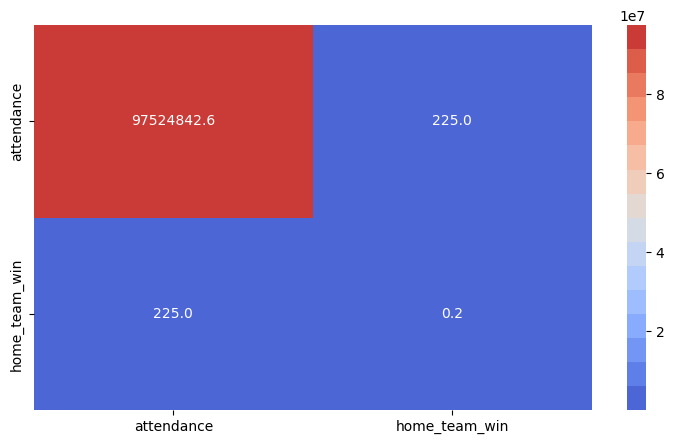

In [44]:

#Оставляем в таблце только нужные колонки
corr_table = data.loc[:, ['attendance', 'home_team_win']]
#correlation_matrix = np.corrcoef(corr_table)
correlation_matrix = corr_table.cov()
correlation_matrix
f, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.1f', ax=ax, cmap=sns.color_palette('coolwarm', 16))
#plt.show()

# 19. Правда ли что большинство проигрышных домашних матчей приходятся на Субботу и Воскресенье?

In [97]:
#tableValues = data.groupby(['home_team_loss','day_of_week'],as_index=False)
tableValues = data.groupby(by=['day_of_week'],as_index=False)['home_team_loss'].sum()
#.groupby(['home_team_loss','day_of_week']).mean()
tableValues = tableValues.sort_values(by=['home_team_loss'],ascending=False)

print('Большинство проигрышей домашних матчей приходится на', tableValues.iloc[0,0], tableValues.iloc[1,0])
tableValues

Большинство проигрышей домашних матчей приходится на Sunday Tuesday


,day_of_week,home_team_loss
3,Sunday,190
5,Tuesday,187
0,Friday,184
2,Saturday,175
6,Wednesday,167
1,Monday,131
4,Thursday,124


# 20. Правда ли что наибольшее количество ранов происходит в холодную погоду? (Холодной погодой считается погода ниже 0 градусов)

In [107]:
tableValues = data.copy()
tableValues['is_cold'] = data['temperature'].apply(lambda x: 'Холодная' if (x-32)*1.8 < 0 else 'Теплая')

tableValues = tableValues.groupby(by=['is_cold'],as_index=False)['total_runs'].sum()
tableValues = tableValues.sort_values(by=['total_runs'],ascending=False)

print(tableValues.iloc[0,0],'погода имеет большее количество РАНОВ')


Теплая погода имеет большее количество РАНОВ
